# 🧠 AVC - Notebook Final (Com Matriz de Confusão)

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

In [20]:
df = pd.read_csv("dataset/stroke_risk_dataset.csv")
df.head()

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1


In [21]:
# Separação correta
y = df['At Risk (Binary)']
X = df.drop(columns=['At Risk (Binary)', 'Stroke Risk (%)'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [22]:
# Modelos
knn = KNeighborsClassifier(n_neighbors=5)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

knn.fit(X_train, y_train)
rf.fit(X_train, y_train);


=== KNN ===
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4892
           1       0.91      0.93      0.92      9108

    accuracy                           0.89     14000
   macro avg       0.89      0.88      0.88     14000
weighted avg       0.89      0.89      0.89     14000

ROC AUC: 0.9557205848344442


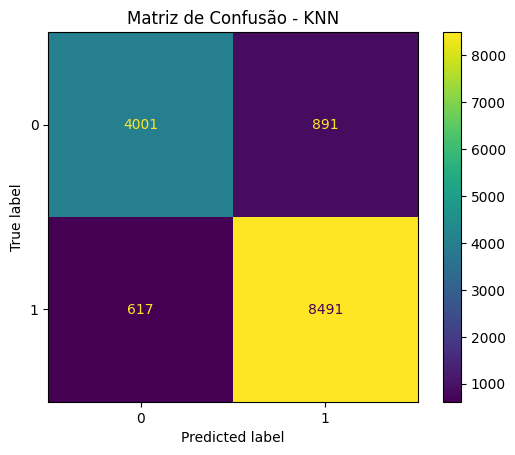


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      4892
           1       0.95      0.97      0.96      9108

    accuracy                           0.95     14000
   macro avg       0.95      0.94      0.94     14000
weighted avg       0.95      0.95      0.95     14000

ROC AUC: 0.9912450049752745


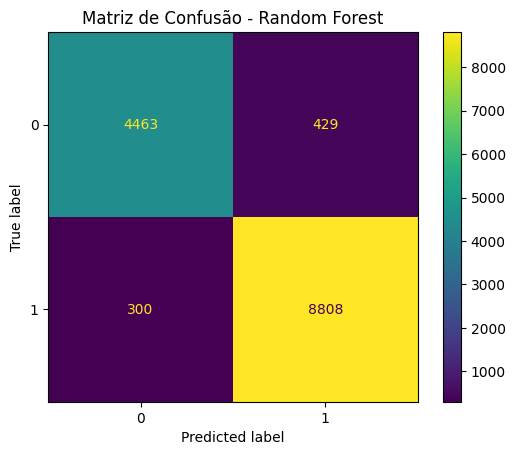

In [23]:
# Avaliação + MATRIZ DE CONFUSÃO
models = {'KNN': knn, 'Random Forest': rf}

for name, model in models.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred))
    print('ROC AUC:', roc_auc_score(y_test, prob))

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão - {name}")
    plt.show()

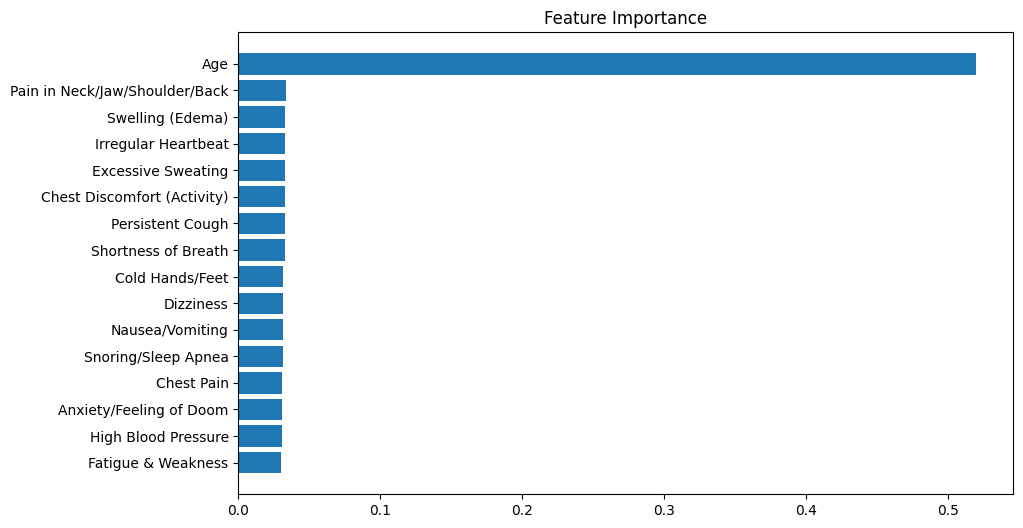

In [24]:
# Feature Importance
importances = rf.feature_importances_
feat_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
feat_df = feat_df.sort_values(by='importance')

plt.figure(figsize=(10,6))
plt.barh(feat_df['feature'], feat_df['importance'])
plt.title('Feature Importance')
plt.show()

In [25]:
# Simulador
input_dict = {}
for col in X.columns:
    input_dict[col] = float(input(f"Digite {col}: "))

input_df = pd.DataFrame([input_dict])
input_scaled = scaler.transform(input_df)

prob = rf.predict_proba(input_scaled)[0][1]

print(f"Probabilidade de AVC: {prob:.2f}")
print('🚨 Emergência' if prob>0.7 else '✅ Não emergencial')

KeyboardInterrupt: Interrupted by user